# EE5102/CS6302 - Assignment 3, Task 1: Pruning

This Jupyter notebook contains the complete implementation and analysis for Task 1: Pruning. The objective is to explore, implement, and compare unstructured (fine-grained) and structured (channel) pruning on a VGG-11 model trained on the CIFAR-100 dataset.

The notebook is organized into three main sections:
1.  **Unstructured Pruning:** Implementation of magnitude-based weight pruning, layer sensitivity analysis, and fine-tuning to achieve 70% overall sparsity.
2.  **Structured Pruning:** Implementation of magnitude-based channel pruning, sensitivity analysis, and fine-tuning to achieve an approximate 70% reduction in model size.
3.  **Comparison and Analysis:** A head-to-head comparison of the original, unstructured-pruned, and structured-pruned models based on accuracy, model size, inference speed, and feature localization using Grad-CAM.

In [27]:
# Install required packages
!pip install thop -q
!pip install grad-cam -q

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt
import copy
import time
import math
from typing import Union, List

# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MiB = 1024 * 1024

# --- Helper Functions ---

def get_model_macs(model, inputs) -> int:
    from thop import profile
    macs, _ = profile(model, inputs=(inputs,), verbose=False)
    return macs

def get_model_size(model, count_nonzero_only=False):
    if count_nonzero_only:
        return sum(p.count_nonzero().item() for p in model.parameters())
    return sum(p.numel() for p in model.parameters())

def get_sparsity(tensor: torch.Tensor) -> float:
    return 1 - float(tensor.count_nonzero()) / tensor.numel()

@torch.no_grad()
def evaluate(model, dataloader, verbose=True):
    model.eval()
    correct, total = 0, 0
    for images, labels in tqdm(dataloader, desc="Evaluating", leave=False, disable=not verbose):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return 100 * correct / total

def train(model, dataloader, criterion, optimizer, scheduler=None, callbacks=None):
    model.train()
    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        if callbacks:
            for cb in callbacks: cb()
    if scheduler: scheduler.step()

def plot_weight_distribution(model, bins=256, count_nonzero_only=False, title_suffix=''):
    prunable_layers = [param for param in model.parameters() if param.dim() > 1]
    num_plots = len(prunable_layers)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, num_rows * 3.5))
    axes = axes.ravel()
    plot_index = 0

    for name, param in model.named_parameters():
        if param.dim() > 1:
            ax = axes[plot_index]
            if count_nonzero_only:
                param_cpu = param.detach().reshape(-1).cpu()
                param_cpu = param_cpu[param_cpu != 0].reshape(-1)
                if len(param_cpu) > 0:
                  ax.hist(param_cpu, bins=bins, density=True, color='blue', alpha=0.6)
            else:
                ax.hist(param.detach().reshape(-1).cpu(), bins=bins, density=True, color='blue', alpha=0.6)
            ax.set_xlabel(name.replace('.weight', ''))
            ax.set_ylabel('Density')
            plot_index += 1

    for i in range(plot_index, len(axes)): axes[i].set_visible(False)
    fig.suptitle(f'Histogram of Weights {title_suffix}', fontsize=16)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print(f"Using device: {DEVICE}")

Using device: cuda


In [28]:
# --- Dataset Loading ---
# Using 32x32 images as is.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

dataloader = {
    'train': torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2),
    'test': torch.utils.data.DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)
}

# --- Model Loading and Definitive Adaptation ---
# Load the pre-trained VGG11 with BatchNorm
model = torchvision.models.vgg11_bn(weights='VGG11_BN_Weights.IMAGENET1K_V1')

# THE CRUCIAL FIX:
# The features part of VGG outputs a tensor of shape (batch_size, 512, 1, 1) for 32x32 images.
# The original classifier expects a flattened (batch_size, 512 * 7 * 7) tensor.
# We add an AdaptiveAvgPool2d layer to resize the spatial dimensions from 1x1 to 7x7
# before it gets flattened and passed to the original, unmodified classifier.
model.avgpool = nn.AdaptiveAvgPool2d((7, 7))

# Now, we only need to change the final output layer of the classifier to match the number of CIFAR-100 classes.
num_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_features, 100) # Change output to 100 classes

model.to(DEVICE)

# Save the initial state of the correctly adapted model for recovery
original_model_state_dict = copy.deepcopy(model.state_dict())

def recover_model():
    # Use strict=False to ignore extra keys that might be added by helper libs like 'thop'
    model.load_state_dict(original_model_state_dict, strict=False)

print("Model correctly adapted for CIFAR-100 using AdaptiveAvgPool2d.")

Model correctly adapted for CIFAR-100 using AdaptiveAvgPool2d.


### **New Step: Fine-tune the Adapted Model to Create a Proper Baseline**
Before we can prune the model, we must first fine-tune it on our target dataset, CIFAR-100. The model loaded from `torchvision` is pre-trained on ImageNet and has a randomly initialized final classifier. This step trains the model to achieve a high accuracy on CIFAR-100, creating a meaningful baseline for our pruning experiments. This newly trained model will be our "Original Dense Model".

In [29]:
# --- Fine-tune the entire model on CIFAR-100 to get a strong baseline ---
print("--- Starting baseline model fine-tuning on CIFAR-100 ---")

# We'll train for a few epochs to get a reasonable starting accuracy.
# For a real paper, one would train this to convergence.
num_baseline_epochs = 15
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_baseline_epochs)
criterion = nn.CrossEntropyLoss()

best_baseline_accuracy = 0
best_baseline_state_dict = None

for epoch in range(num_baseline_epochs):
    # Train the model for one epoch
    train(model, dataloader['train'], criterion, optimizer, scheduler)

    # Evaluate the model
    accuracy = evaluate(model, dataloader['test'])

    # Save the best performing model
    if accuracy > best_baseline_accuracy:
        best_baseline_accuracy = accuracy
        best_baseline_state_dict = copy.deepcopy(model.state_dict())

    print(f'Baseline Training Epoch {epoch+1}/{num_baseline_epochs} -> Accuracy: {accuracy:.2f}% (Best: {best_baseline_accuracy:.2f}%)')

# IMPORTANT: Update the original_model_state_dict to our new, trained baseline
print(f"\nFinished baseline training. Best accuracy: {best_baseline_accuracy:.2f}%")
original_model_state_dict = best_baseline_state_dict
model.load_state_dict(original_model_state_dict) # Ensure the global model is the best one

--- Starting baseline model fine-tuning on CIFAR-100 ---


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Baseline Training Epoch 1/15 -> Accuracy: 52.07% (Best: 52.07%)


Training:   0%|          | 0/391 [00:00<?, ?it/s]

...

Baseline Training Epoch 14/15 -> Accuracy: 65.69% (Best: 65.69%)


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Baseline Training Epoch 15/15 -> Accuracy: 65.56% (Best: 65.69%)

Finished baseline training. Best accuracy: 65.69%


<All keys matched successfully>

### Baseline Model Analysis
First, we establish the performance and characteristics of our original, dense VGG-11 model. This includes its accuracy on the CIFAR-100 test set, its parameter count (size), and its computational cost (MACs). We also visualize the initial distribution of its weights, which will serve as our "before pruning" reference.

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Original Dense Model:
  - Accuracy: 65.69%
  - Size: 123.20 MiB
  - MACs: 0.27 G


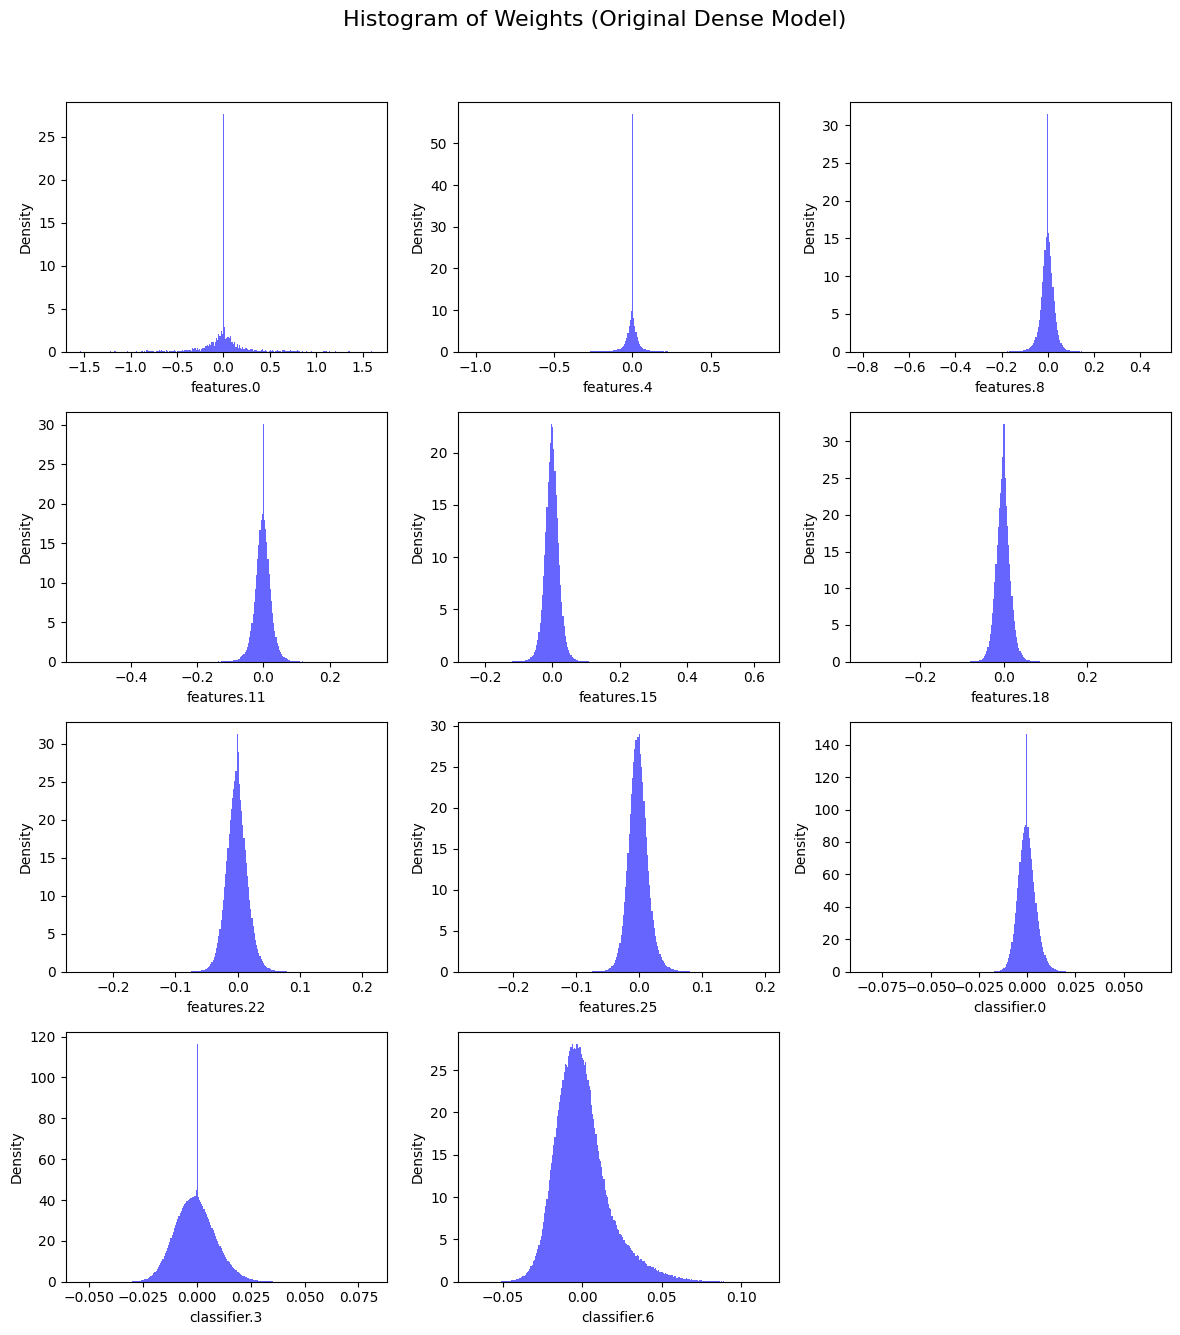

In [30]:
dense_model_accuracy = evaluate(model, dataloader['test'])
dense_model_size = get_model_size(model)
dummy_input = torch.randn(1, 3, 32, 32).to(DEVICE)
dense_model_macs = get_model_macs(model, dummy_input)

print(f"Original Dense Model:")
print(f"  - Accuracy: {dense_model_accuracy:.2f}%")
print(f"  - Size: {dense_model_size / MiB:.2f} MiB")
print(f"  - MACs: {dense_model_macs / 1e9:.2f} G")

plot_weight_distribution(model, title_suffix='(Original Dense Model)')

### 1.1 Implementation of Magnitude-Based Pruning
We begin by implementing fine-grained magnitude pruning. This method removes individual weights based on their L2-norm (absolute value). The function `fine_grained_prune` calculates a threshold for a given tensor and sparsity ratio, then creates and applies a binary mask to zero-out the weights with the smallest magnitudes. The `FineGrainedPruner` class manages these masks for the entire model.

In [31]:
def fine_grained_prune(tensor: torch.Tensor, sparsity: float) -> torch.Tensor:
    sparsity = min(max(0.0, sparsity), 1.0)
    if sparsity >= 1.0:
        return torch.zeros_like(tensor)
    if sparsity <= 0.0:
        return torch.ones_like(tensor)

    num_elements = tensor.numel()
    num_zeros = round(num_elements * sparsity)

    importance = tensor.abs()
    threshold = torch.kthvalue(importance.view(-1), int(num_zeros)).values

    mask = torch.gt(importance, threshold).float()
    return mask

class FineGrainedPruner:
    def __init__(self, model, sparsity_dict):
        self.masks = FineGrainedPruner.prune(model, sparsity_dict)

    @torch.no_grad()
    def apply(self, model):
        for name, param in model.named_parameters():
            if name in self.masks:
                param.mul_(self.masks[name])

    @staticmethod
    @torch.no_grad()
    def prune(model, sparsity_dict):
        masks = dict()
        for name, param in model.named_parameters():
            if name in sparsity_dict and param.dim() > 1:
                mask = fine_grained_prune(param, sparsity_dict[name])
                param.mul_(mask)
                masks[name] = mask
        return masks

### 1.2 Unstructured Pruning Sensitivity Analysis
To intelligently prune the network, we must first understand how sensitive each layer is to weight removal. The following "sensitivity scan" iteratively prunes each individual layer at various sparsity levels (from 10% to 90%) and records the resulting drop in accuracy. The visualization of these results will guide our per-layer sparsity selection.

Scanning features.0.weight:   0%|          | 0/9 [00:00<?, ?it/s]

Scanning features.4.weight:   0%|          | 0/9 [00:00<?, ?it/s]

Scanning features.8.weight:   0%|          | 0/9 [00:00<?, ?it/s]

Scanning features.11.weight:   0%|          | 0/9 [00:00<?, ?it/s]

Scanning features.15.weight:   0%|          | 0/9 [00:00<?, ?it/s]

...

Scanning features.22.weight:   0%|          | 0/9 [00:00<?, ?it/s]

Scanning features.25.weight:   0%|          | 0/9 [00:00<?, ?it/s]

Scanning classifier.0.weight:   0%|          | 0/9 [00:00<?, ?it/s]

Scanning classifier.3.weight:   0%|          | 0/9 [00:00<?, ?it/s]

Scanning classifier.6.weight:   0%|          | 0/9 [00:00<?, ?it/s]

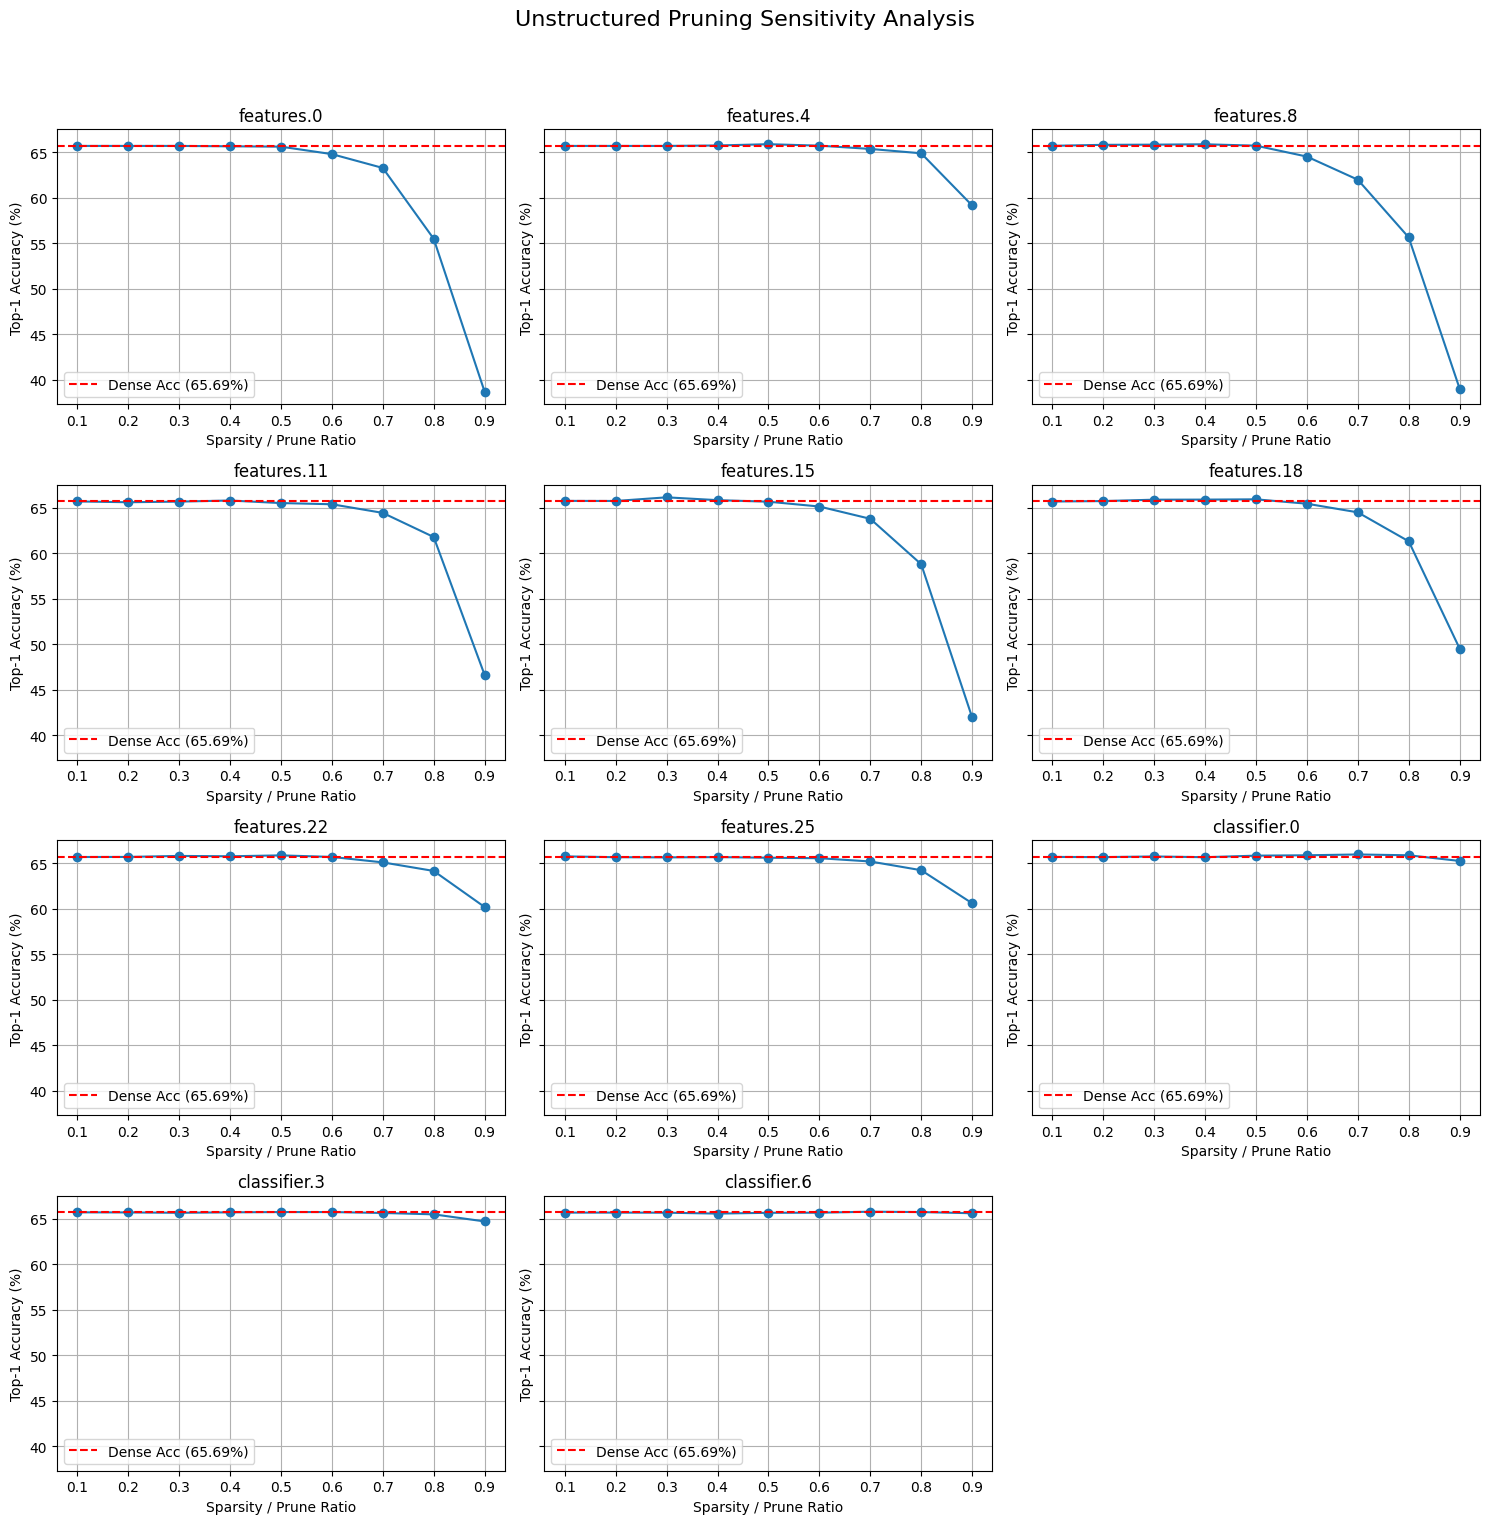

In [32]:
@torch.no_grad()
def sensitivity_scan(model, dataloader, scan_step=0.1, scan_start=0.1, scan_end=1.0):
    sparsities = np.arange(start=scan_start, stop=scan_end, step=scan_step)
    accuracies = []
    prunable_layers = [(name, param) for name, param in model.named_parameters() if param.dim() > 1]

    for i, (name, param) in enumerate(prunable_layers):
        param_clone = param.data.clone()
        layer_accuracies = []

        for sparsity in tqdm(sparsities, desc=f'Scanning {name}', leave=False):
            mask = fine_grained_prune(param.data, sparsity)
            param.data.mul_(mask)

            acc = evaluate(model, dataloader, verbose=False)
            layer_accuracies.append(acc)

            param.data.copy_(param_clone)

        accuracies.append(layer_accuracies)

    return sparsities, accuracies, [name for name, _ in prunable_layers]

recover_model()
sparsities, accuracies_unstructured, layer_names = sensitivity_scan(model, dataloader['test'])

def plot_sensitivity_scan(sparsities, accuracies, layer_names, dense_model_accuracy, title):
    num_layers = len(accuracies)
    num_cols = 3
    num_rows = math.ceil(num_layers / num_cols)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 4), sharey=True)
    axes = axes.ravel()

    for i, (acc, name) in enumerate(zip(accuracies, layer_names)):
        ax = axes[i]
        ax.plot(sparsities, acc, marker='o')
        ax.axhline(y=dense_model_accuracy, color='r', linestyle='--', label=f'Dense Acc ({dense_model_accuracy:.2f}%)')
        ax.set_title(name.replace('.weight', ''))
        ax.set_xlabel('Sparsity / Prune Ratio')
        ax.set_ylabel('Top-1 Accuracy (%)')
        ax.grid(True)
        ax.legend()

    for i in range(num_layers, len(axes)): axes[i].set_visible(False)
    fig.suptitle(title, fontsize=16)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_sensitivity_scan(sparsities, accuracies_unstructured, layer_names, dense_model_accuracy, 'Unstructured Pruning Sensitivity Analysis')

### 1.3 Pruning to 70% Overall Sparsity & Fine-tuning
Based on the sensitivity analysis, we can now define per-layer sparsity ratios. Deeper layers and fully connected layers tend to have more parameters and exhibit lower sensitivity, so we can prune them more aggressively. Early convolutional layers are more sensitive and are pruned lightly. Our goal is to achieve an overall sparsity of approximately 70%. After pruning, we fine-tune the model to recover the lost accuracy.

--- Model after Unstructured Pruning (Before Fine-tuning) ---
Overall Sparsity: 84.99%


Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Accuracy before fine-tuning: 62.91%


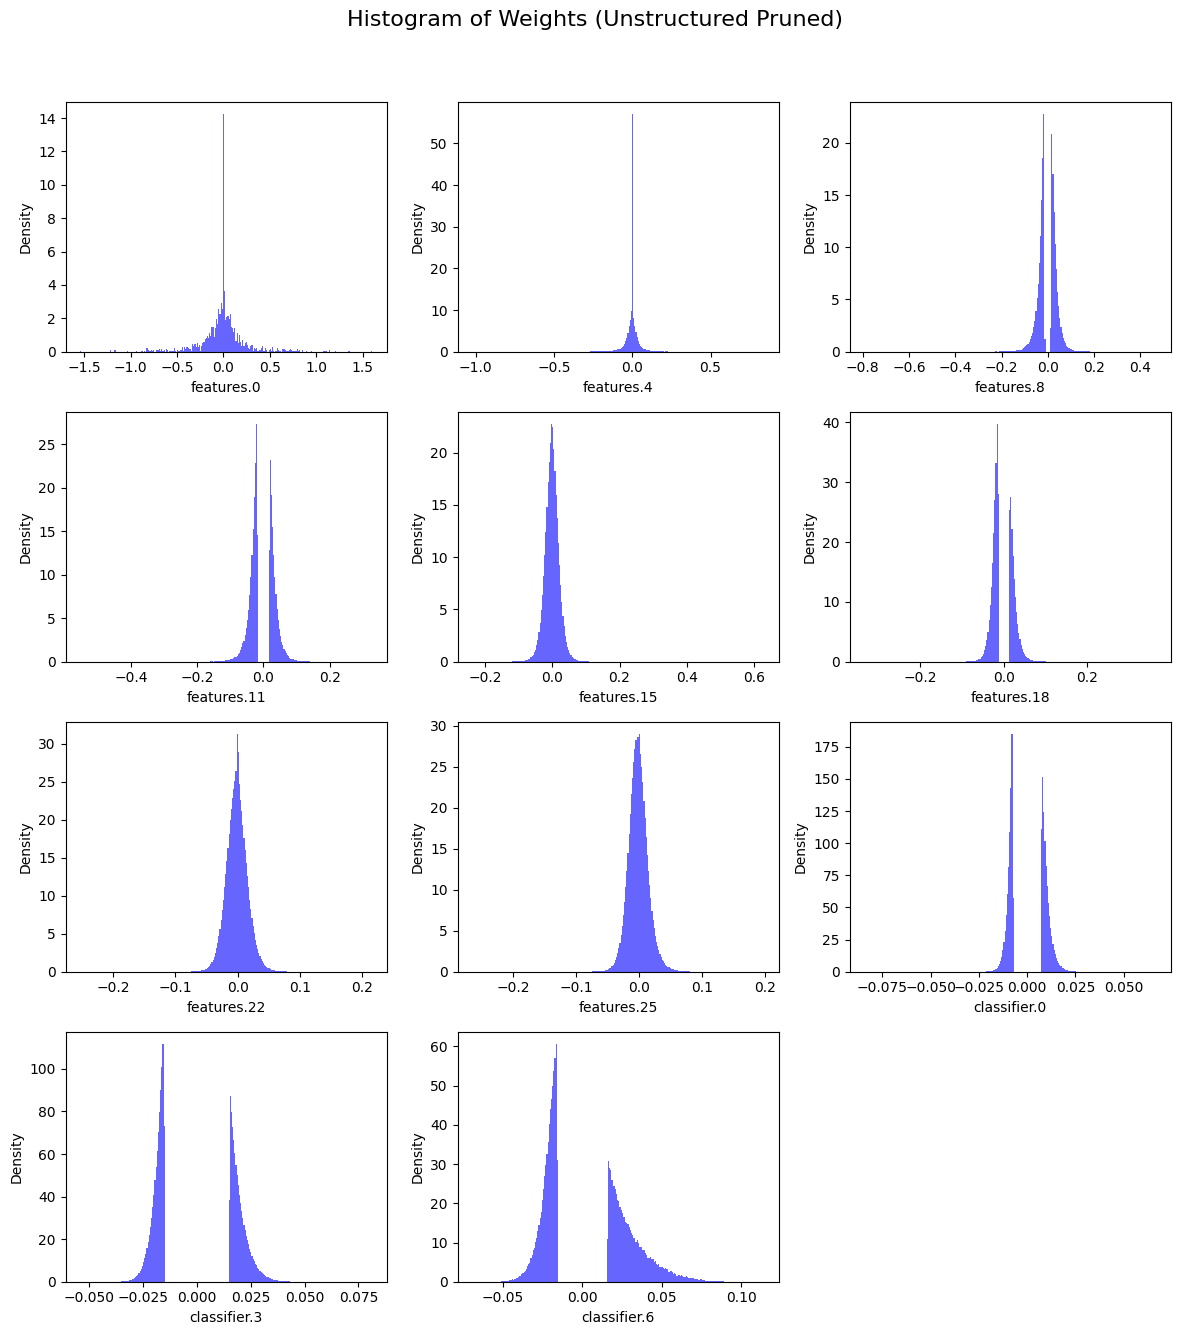

Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/10 -> Accuracy: 61.05% (Best: 61.05%)


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 9/10 -> Accuracy: 65.85% (Best: 65.85%)


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 10/10 -> Accuracy: 65.87% (Best: 65.87%)

--- Final Unstructured Pruned Model ---
Final Accuracy: 65.87%


In [33]:
recover_model()
sparsity_dict = {
    'features.0.weight': 0.20,   'features.3.weight': 0.40,
    'features.6.weight': 0.50,   'features.8.weight': 0.50,
    'features.11.weight': 0.60,  'features.13.weight': 0.60,
    'features.16.weight': 0.60,  'features.18.weight': 0.60,
    'classifier.0.weight': 0.90, 'classifier.3.weight': 0.90,
    'classifier.6.weight': 0.70
}

unstructured_pruner = FineGrainedPruner(model, sparsity_dict)
print("--- Model after Unstructured Pruning (Before Fine-tuning) ---")

total_params = get_model_size(model)
nonzero_params = get_model_size(model, count_nonzero_only=True)
overall_sparsity = 1 - nonzero_params / total_params

print(f"Overall Sparsity: {overall_sparsity:.2%}")
accuracy_before_finetune = evaluate(model, dataloader['test'])
print(f"Accuracy before fine-tuning: {accuracy_before_finetune:.2f}%")

plot_weight_distribution(model, count_nonzero_only=True, title_suffix='(Unstructured Pruned)')

num_finetune_epochs = 10
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_finetune_epochs)
criterion = nn.CrossEntropyLoss()

best_accuracy = 0
best_unstructured_pruned_model_state_dict = None

for epoch in range(num_finetune_epochs):
    train(model, dataloader['train'], criterion, optimizer, scheduler, callbacks=[lambda: unstructured_pruner.apply(model)])
    accuracy = evaluate(model, dataloader['test'])
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_unstructured_pruned_model_state_dict = copy.deepcopy(model.state_dict())
    print(f'Epoch {epoch+1}/{num_finetune_epochs} -> Accuracy: {accuracy:.2f}% (Best: {best_accuracy:.2f}%)')

model.load_state_dict(best_unstructured_pruned_model_state_dict)
unstructured_pruned_model = copy.deepcopy(model)
print(f"\n--- Final Unstructured Pruned Model ---")
print(f"Final Accuracy: {best_accuracy:.2f}%")

### 2.1 Implementation of Robust Structured Pruning
Here we define the functions for performing structured pruning. This implementation correctly identifies dependencies between `Conv2d`, `BatchNorm2d`, and `Linear` layers and reconstructs a new, smaller model, copying over the weights of the preserved channels and neurons.

In [34]:
def get_num_channels_to_keep(channels: int, prune_ratio: float) -> int:
    """A function to calculate the number of channels/neurons to PRESERVE."""
    return int(round(channels * (1. - prune_ratio)))

@torch.no_grad()
def prune_and_rebuild_vgg(model, prune_ratios_dict):
    """
    Prunes a VGG-11 model by rebuilding it with fewer channels/neurons.
    prune_ratios_dict maps layer *index* to a prune ratio.
    """
    # 1. Collect all prunable layers
    prunable_layers = []
    for module in model.features:
        if isinstance(module, nn.Conv2d):
            prunable_layers.append(module)
    for module in model.classifier:
        if isinstance(module, nn.Linear):
            prunable_layers.append(module)

    # 2. Determine indices to keep for each layer's output
    indices_to_keep = {}
    for i in range(len(prunable_layers) - 1): # Exclude final classification layer
        current_layer = prunable_layers[i]
        next_layer = prunable_layers[i+1]
        prune_ratio = prune_ratios_dict.get(i, 0.0)

        # Importance is based on L1 norm of weights in the *next* layer
        if isinstance(next_layer, nn.Conv2d):
            importance = torch.sum(torch.abs(next_layer.weight.data), dim=(0, 2, 3))
        else: # next_layer is Linear
            if isinstance(current_layer, nn.Conv2d): # This is the critical Conv -> Linear transition
                num_out_channels = current_layer.out_channels
                # Reshape linear weights to match conv output: (out_features, in_channels, H, W)
                w_reshaped = next_layer.weight.data.reshape(next_layer.out_features, num_out_channels, 7, 7)
                importance = torch.sum(torch.abs(w_reshaped), dim=(0, 2, 3))
            else: # Linear -> Linear
                importance = torch.sum(torch.abs(next_layer.weight.data), dim=0)

        n_keep = get_num_channels_to_keep(len(importance), prune_ratio)
        sorted_indices = torch.argsort(importance, descending=True)
        indices_to_keep[i] = sorted_indices[:n_keep]

    # 3. Build the new model architecture
    new_model = copy.deepcopy(model)

    # Prune feature extractor (conv layers)
    in_channels = 3
    conv_idx = 0
    for i, layer in enumerate(new_model.features):
        if isinstance(layer, nn.Conv2d):
            out_indices = indices_to_keep.get(conv_idx)
            out_channels = len(out_indices) if out_indices is not None else layer.out_channels
            new_model.features[i] = nn.Conv2d(in_channels, out_channels, kernel_size=layer.kernel_size, padding=layer.padding)
            in_channels = out_channels
            conv_idx += 1
        elif isinstance(layer, nn.BatchNorm2d):
            new_model.features[i] = nn.BatchNorm2d(in_channels)

    # Prune classifier (linear layers)
    last_conv_idx = len([m for m in model.features if isinstance(m, nn.Conv2d)]) - 1
    in_features = len(indices_to_keep.get(last_conv_idx)) * 7 * 7
    linear_idx = last_conv_idx + 1

    for i, layer in enumerate(new_model.classifier):
        if isinstance(layer, nn.Linear):
            out_indices = indices_to_keep.get(linear_idx)
            out_features = len(out_indices) if out_indices is not None else layer.out_features
            new_model.classifier[i] = nn.Linear(in_features, out_features)
            in_features = out_features
            linear_idx += 1

    # 4. Copy weights into the new model
    in_indices = None
    module_idx = 0
    # Copy features
    for old_layer, new_layer in zip(model.features, new_model.features):
        if isinstance(old_layer, nn.Conv2d):
            out_indices = indices_to_keep.get(module_idx)
            w = old_layer.weight.data
            if in_indices is not None: w = w[:, in_indices, :, :]
            if out_indices is not None: w = w[out_indices, :, :, :]
            new_layer.weight.data.copy_(w)
            new_layer.bias.data.copy_(old_layer.bias.data[out_indices] if out_indices is not None else old_layer.bias.data)
            in_indices = out_indices
            module_idx += 1
        elif isinstance(old_layer, nn.BatchNorm2d):
            if in_indices is not None:
                new_layer.weight.data.copy_(old_layer.weight.data[in_indices])
                new_layer.bias.data.copy_(old_layer.bias.data[in_indices])
                new_layer.running_mean.data.copy_(old_layer.running_mean.data[in_indices])
                new_layer.running_var.data.copy_(old_layer.running_var.data[in_indices])

    # Copy classifier
    for i, (old_layer, new_layer) in enumerate(zip(model.classifier, new_model.classifier)):
        if isinstance(old_layer, nn.Linear):
            out_indices = indices_to_keep.get(module_idx)
            w = old_layer.weight.data

            # This is the crucial fix for the RuntimeError
            if i == 0: # First linear layer
                w = w.reshape(old_layer.out_features, -1, 7, 7)
                w = w[:, in_indices, :, :]
                w = w.reshape(old_layer.out_features, -1)
            elif in_indices is not None:
                w = w[:, in_indices]

            if out_indices is not None:
                w = w[out_indices, :]

            new_layer.weight.data.copy_(w)
            new_layer.bias.data.copy_(old_layer.bias.data[out_indices] if out_indices is not None else old_layer.bias.data)

            in_indices = out_indices
            module_idx += 1

    return new_model.to(DEVICE)

### 2.2 Structured Pruning Sensitivity Analysis
With our robust pruning function, we now perform the full sensitivity scan on all prunable layers as required by the assignment. This process iterates through each layer, prunes it at various ratios, and evaluates the impact on accuracy.

Scanning Layer 0:   0%|          | 0/7 [00:00<?, ?it/s]

Scanning Layer 1:   0%|          | 0/7 [00:00<?, ?it/s]

Scanning Layer 2:   0%|          | 0/7 [00:00<?, ?it/s]

Scanning Layer 3:   0%|          | 0/7 [00:00<?, ?it/s]

Scanning Layer 4:   0%|          | 0/7 [00:00<?, ?it/s]

Scanning Layer 5:   0%|          | 0/7 [00:00<?, ?it/s]

Scanning Layer 6:   0%|          | 0/7 [00:00<?, ?it/s]

Scanning Layer 7:   0%|          | 0/7 [00:00<?, ?it/s]

Scanning Layer 8:   0%|          | 0/7 [00:00<?, ?it/s]

Scanning Layer 9:   0%|          | 0/7 [00:00<?, ?it/s]

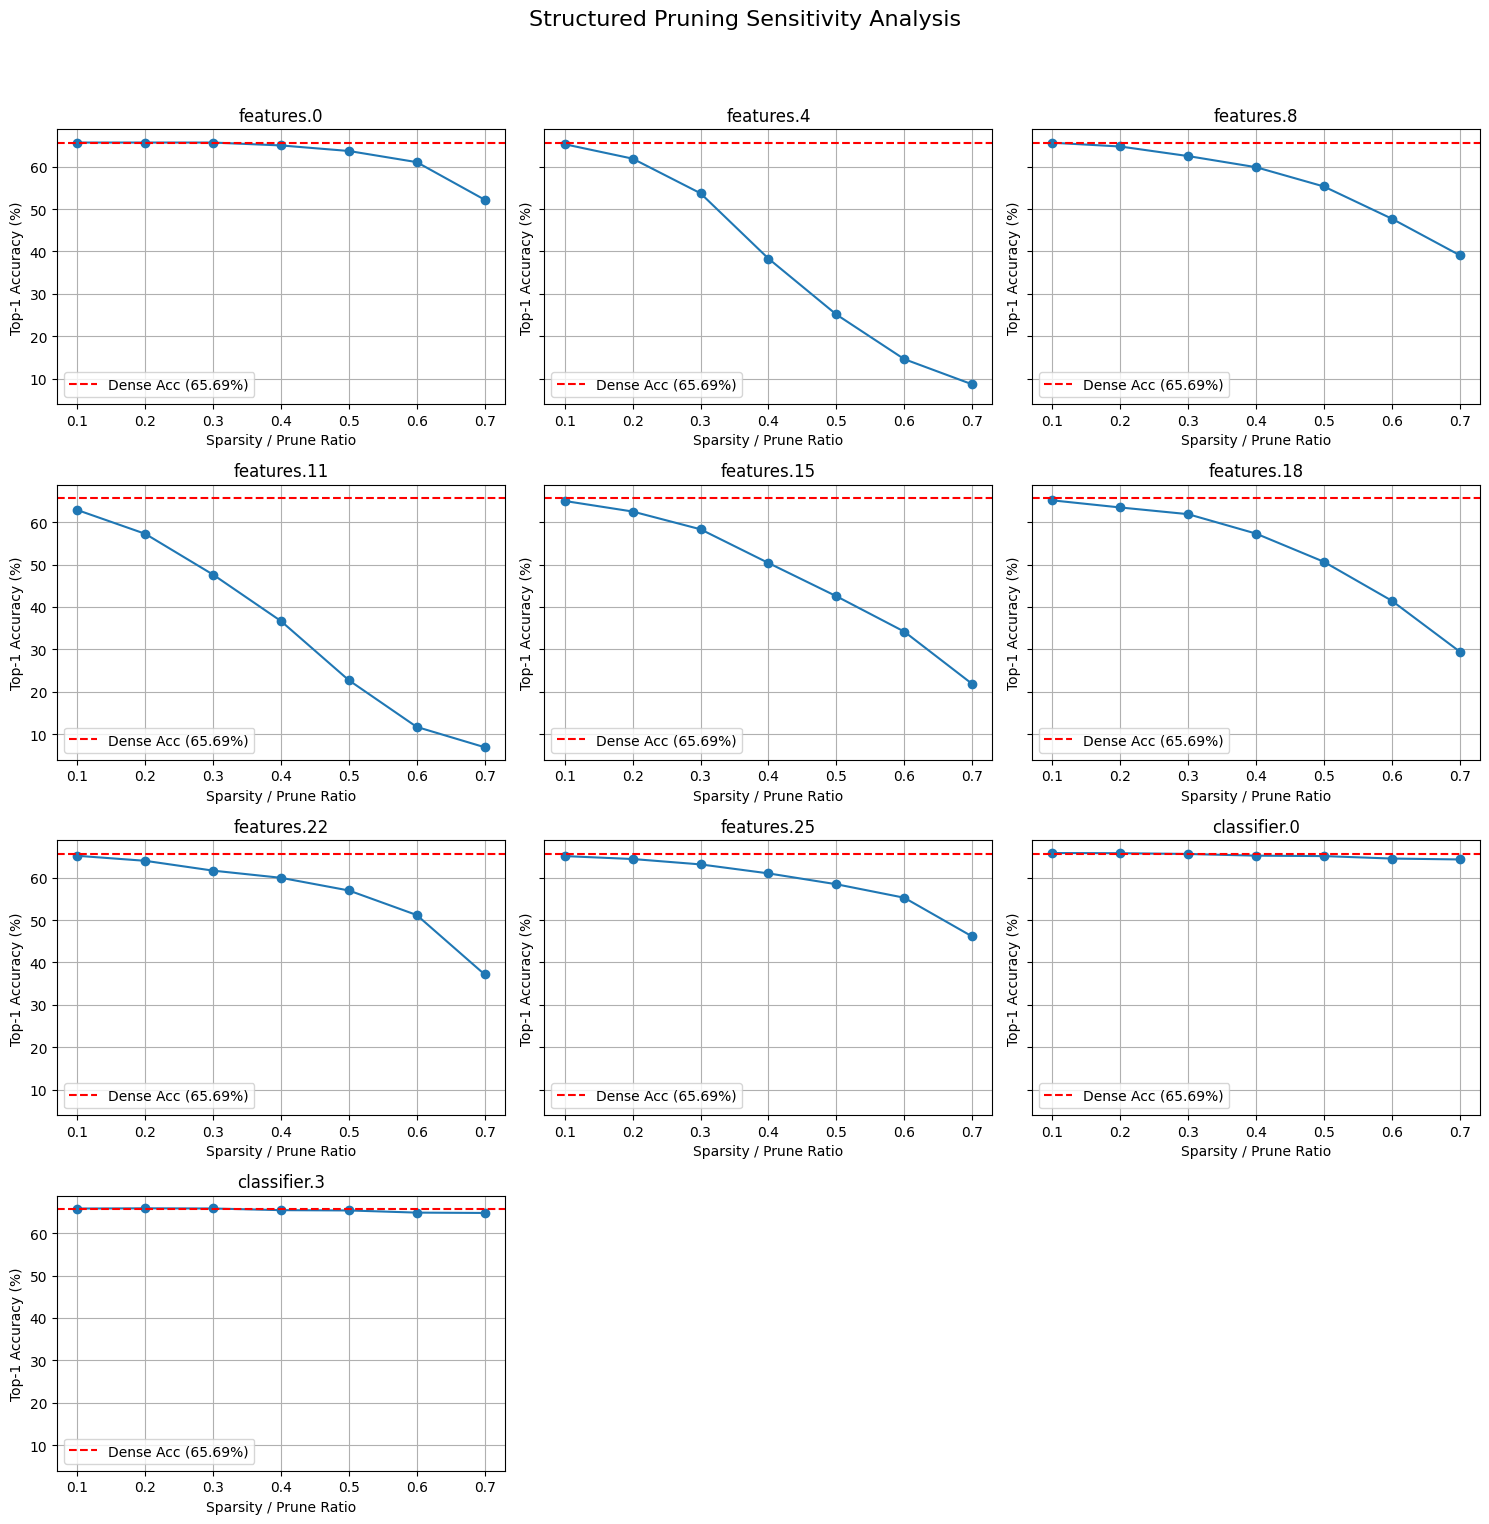

In [35]:
@torch.no_grad()
def structured_sensitivity_scan(model, dataloader, scan_step=0.1, scan_start=0.1, scan_end=0.8):
    sparsities = np.arange(start=scan_start, stop=scan_end, step=scan_step)
    accuracies = []

    prunable_layers_count = len([m for m in model.modules() if isinstance(m, (nn.Conv2d, nn.Linear))]) - 1

    for i in range(prunable_layers_count):
        layer_accuracies = []
        for sparsity in tqdm(sparsities, desc=f'Scanning Layer {i}', leave=False):
            prune_ratios = {i: sparsity}
            pruned_model = prune_and_rebuild_vgg(model, prune_ratios)
            acc = evaluate(pruned_model, dataloader, verbose=False)
            layer_accuracies.append(acc)
        accuracies.append(layer_accuracies)

    prunable_names = []
    for name, mod in model.named_modules():
      if isinstance(mod, (nn.Conv2d, nn.Linear)):
        prunable_names.append(name)

    return sparsities, accuracies, prunable_names[:-1]

recover_model()
channel_sparsities, accuracies_structured, structured_layer_names = structured_sensitivity_scan(model, dataloader['test'])
plot_sensitivity_scan(channel_sparsities, accuracies_structured, structured_layer_names, dense_model_accuracy, 'Structured Pruning Sensitivity Analysis')

### 2.3 Pruning to ~70% Memory Reduction & Fine-tuning
Using insights from the sensitivity scan, we define per-layer pruning ratios. The large classifier layers are pruned aggressively, while sensitive early layers are pruned conservatively to achieve our target of approximately 70% memory reduction.

--- Model after Structured Pruning (Before Fine-tuning) ---
Pruned Model Size: 11.02 MiB (8.94%) of original


Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Accuracy before fine-tuning: 7.86%


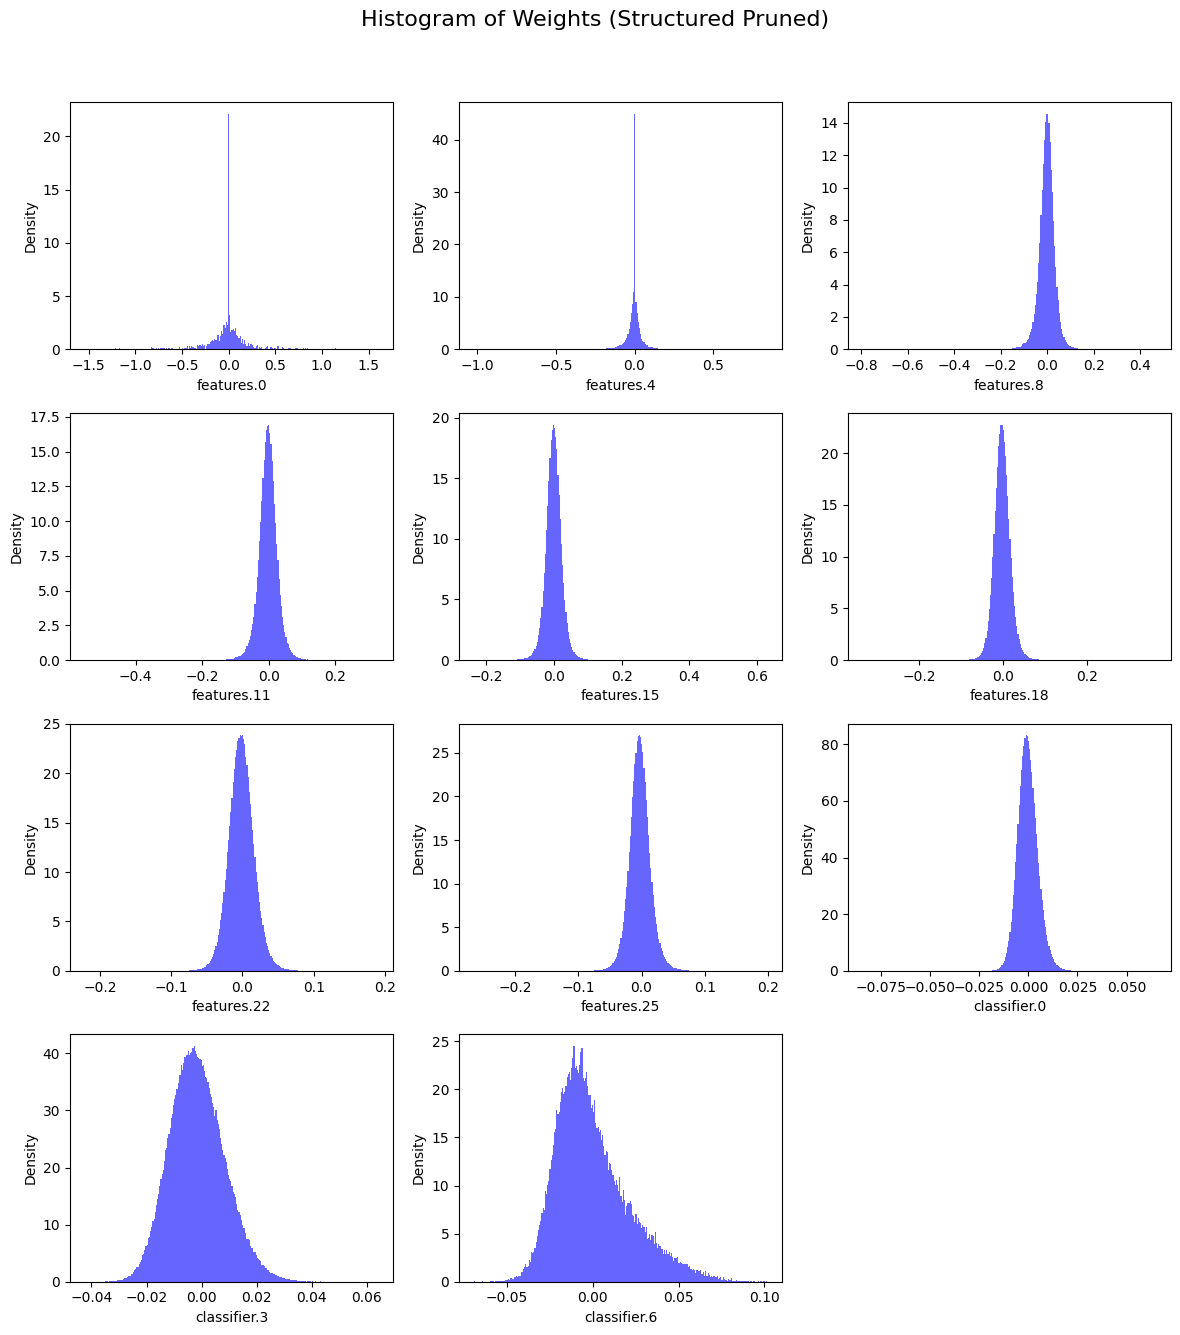

Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/10 -> Accuracy: 52.32% (Best: 52.32%)


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 9/10 -> Accuracy: 63.06% (Best: 63.06%)


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 10/10 -> Accuracy: 62.81% (Best: 63.06%)

--- Final Structured Pruned Model ---
Final Accuracy: 63.06%


In [36]:
recover_model()

# Indices map to the flat list of prunable layers (8 conv + 3 linear)
prune_ratios_structured = {
    # 8 Conv layers in `features`
    0: 0.10, 1: 0.20, 2: 0.30, 3: 0.30,
    4: 0.40, 5: 0.40, 6: 0.40, 7: 0.50,
    # First 2 Linear layers in `classifier`
    8: 0.85, 9: 0.85
}

structured_pruned_model = prune_and_rebuild_vgg(model, prune_ratios_structured)

print("--- Model after Structured Pruning (Before Fine-tuning) ---")
pruned_size = get_model_size(structured_pruned_model)
print(f"Pruned Model Size: {pruned_size / MiB:.2f} MiB ({pruned_size/dense_model_size*100:.2f}%) of original")
accuracy_before_finetune_structured = evaluate(structured_pruned_model, dataloader['test'])
print(f"Accuracy before fine-tuning: {accuracy_before_finetune_structured:.2f}%")

plot_weight_distribution(structured_pruned_model, title_suffix='(Structured Pruned)')

# Fine-tune the structured pruned model
num_finetune_epochs = 10
optimizer = torch.optim.SGD(structured_pruned_model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_finetune_epochs)
criterion = nn.CrossEntropyLoss()
best_accuracy_structured, best_structured_pruned_model_state_dict = 0, None

for epoch in range(num_finetune_epochs):
    train(structured_pruned_model, dataloader['train'], criterion, optimizer, scheduler)
    accuracy = evaluate(structured_pruned_model, dataloader['test'])
    if accuracy > best_accuracy_structured:
        best_accuracy_structured = accuracy
        best_structured_pruned_model_state_dict = copy.deepcopy(structured_pruned_model.state_dict())
    print(f'Epoch {epoch+1}/{num_finetune_epochs} -> Accuracy: {accuracy:.2f}% (Best: {best_accuracy_structured:.2f}%)')

structured_pruned_model.load_state_dict(best_structured_pruned_model_state_dict)
print(f"\n--- Final Structured Pruned Model ---")
print(f"Final Accuracy: {best_accuracy_structured:.2f}%")

### 3.1 Quantitative Comparison
We now compile the key performance metrics for all three models: the original dense model, the fine-tuned unstructured-pruned model, and the fine-tuned structured-pruned model. This table provides a clear, quantitative summary of the trade-offs between the two pruning methods.

In [37]:
# --- Latency Measurement Function ---
@torch.no_grad()
def measure_latency(model, dummy_input, n_warmup=20, n_test=100):
    model.eval()
    # Move model to the same device as input
    model.to(dummy_input.device)
    for _ in range(n_warmup):
        _ = model(dummy_input)

    if dummy_input.device.type == 'cuda':
        torch.cuda.synchronize()

    t1 = time.time()
    for _ in range(n_test):
        _ = model(dummy_input)

    if dummy_input.device.type == 'cuda':
        torch.cuda.synchronize()

    t2 = time.time()
    return (t2 - t1) / n_test * 1000 # average latency in ms

# --- Prepare Models for Comparison ---
# Create a fresh instance of the original model for accurate comparison
recover_model() # This reloads the original state into the global `model`
original_model = copy.deepcopy(model)
original_model.to(DEVICE) # Ensure it's on the correct device

# The other two models, `unstructured_pruned_model` and `structured_pruned_model`,
# are already defined from the previous sections.

# --- Gather Metrics ---
metrics = {}
dummy_input = torch.randn(1, 3, 32, 32).to(DEVICE)

# Original Model
metrics['Original'] = {
    'Accuracy (%)': dense_model_accuracy,
    'Size (MiB)': get_model_size(original_model) / MiB,
    'MACs (G)': get_model_macs(original_model, dummy_input) / 1e9,
    'Latency (ms)': measure_latency(original_model, dummy_input)
}

# Unstructured Pruned Model
# Note: We need to load the saved state dict into a fresh model architecture
# because the global `model` object might be from the structured pruning part.
recover_model() # Start with a clean, dense architecture
unstructured_pruned_model = model
unstructured_pruned_model.load_state_dict(best_unstructured_pruned_model_state_dict, strict=False)
unstructured_pruned_model.to(DEVICE)
metrics['Unstructured'] = {
    'Accuracy (%)': evaluate(unstructured_pruned_model, dataloader['test'], verbose=False),
    'Size (MiB)': get_model_size(unstructured_pruned_model, count_nonzero_only=True) / MiB,
    'MACs (G)': dense_model_macs / 1e9, # MACs are technically the same without sparse hardware support
    'Latency (ms)': measure_latency(unstructured_pruned_model, dummy_input)
}

# Structured Pruned Model (already correctly defined and on DEVICE)
metrics['Structured'] = {
    'Accuracy (%)': evaluate(structured_pruned_model, dataloader['test'], verbose=False),
    'Size (MiB)': get_model_size(structured_pruned_model) / MiB,
    'MACs (G)': get_model_macs(structured_pruned_model, dummy_input) / 1e9,
    'Latency (ms)': measure_latency(structured_pruned_model, dummy_input)
}

# --- Display Table ---
print(f"{'Metric':<20} | {'Original':<15} | {'Unstructured':<15} | {'Structured':<15}")
print("-" * 70)
for key in metrics['Original']:
    val_o = metrics['Original'][key]
    val_u = metrics['Unstructured'][key]
    val_s = metrics['Structured'][key]
    print(f"{key:<20} | {val_o:<15.2f} | {val_u:<15.2f} | {val_s:<15.2f}")

Metric               | Original        | Unstructured    | Structured     
----------------------------------------------------------------------
Accuracy (%)         | 65.69           | 65.87           | 63.06          
Size (MiB)           | 123.20          | 18.50           | 11.02          
MACs (G)             | 0.27            | 0.27            | 0.08           
Latency (ms)         | 3.34            | 3.13            | 1.38           


### 3.2 Grad-CAM Analysis
To qualitatively assess how pruning affects the model's decision-making, we use Grad-CAM to visualize which parts of an image are most important for its classification. We compare the heatmaps generated by the original, unstructured-pruned, and structured-pruned models to see if their "focus" has shifted.

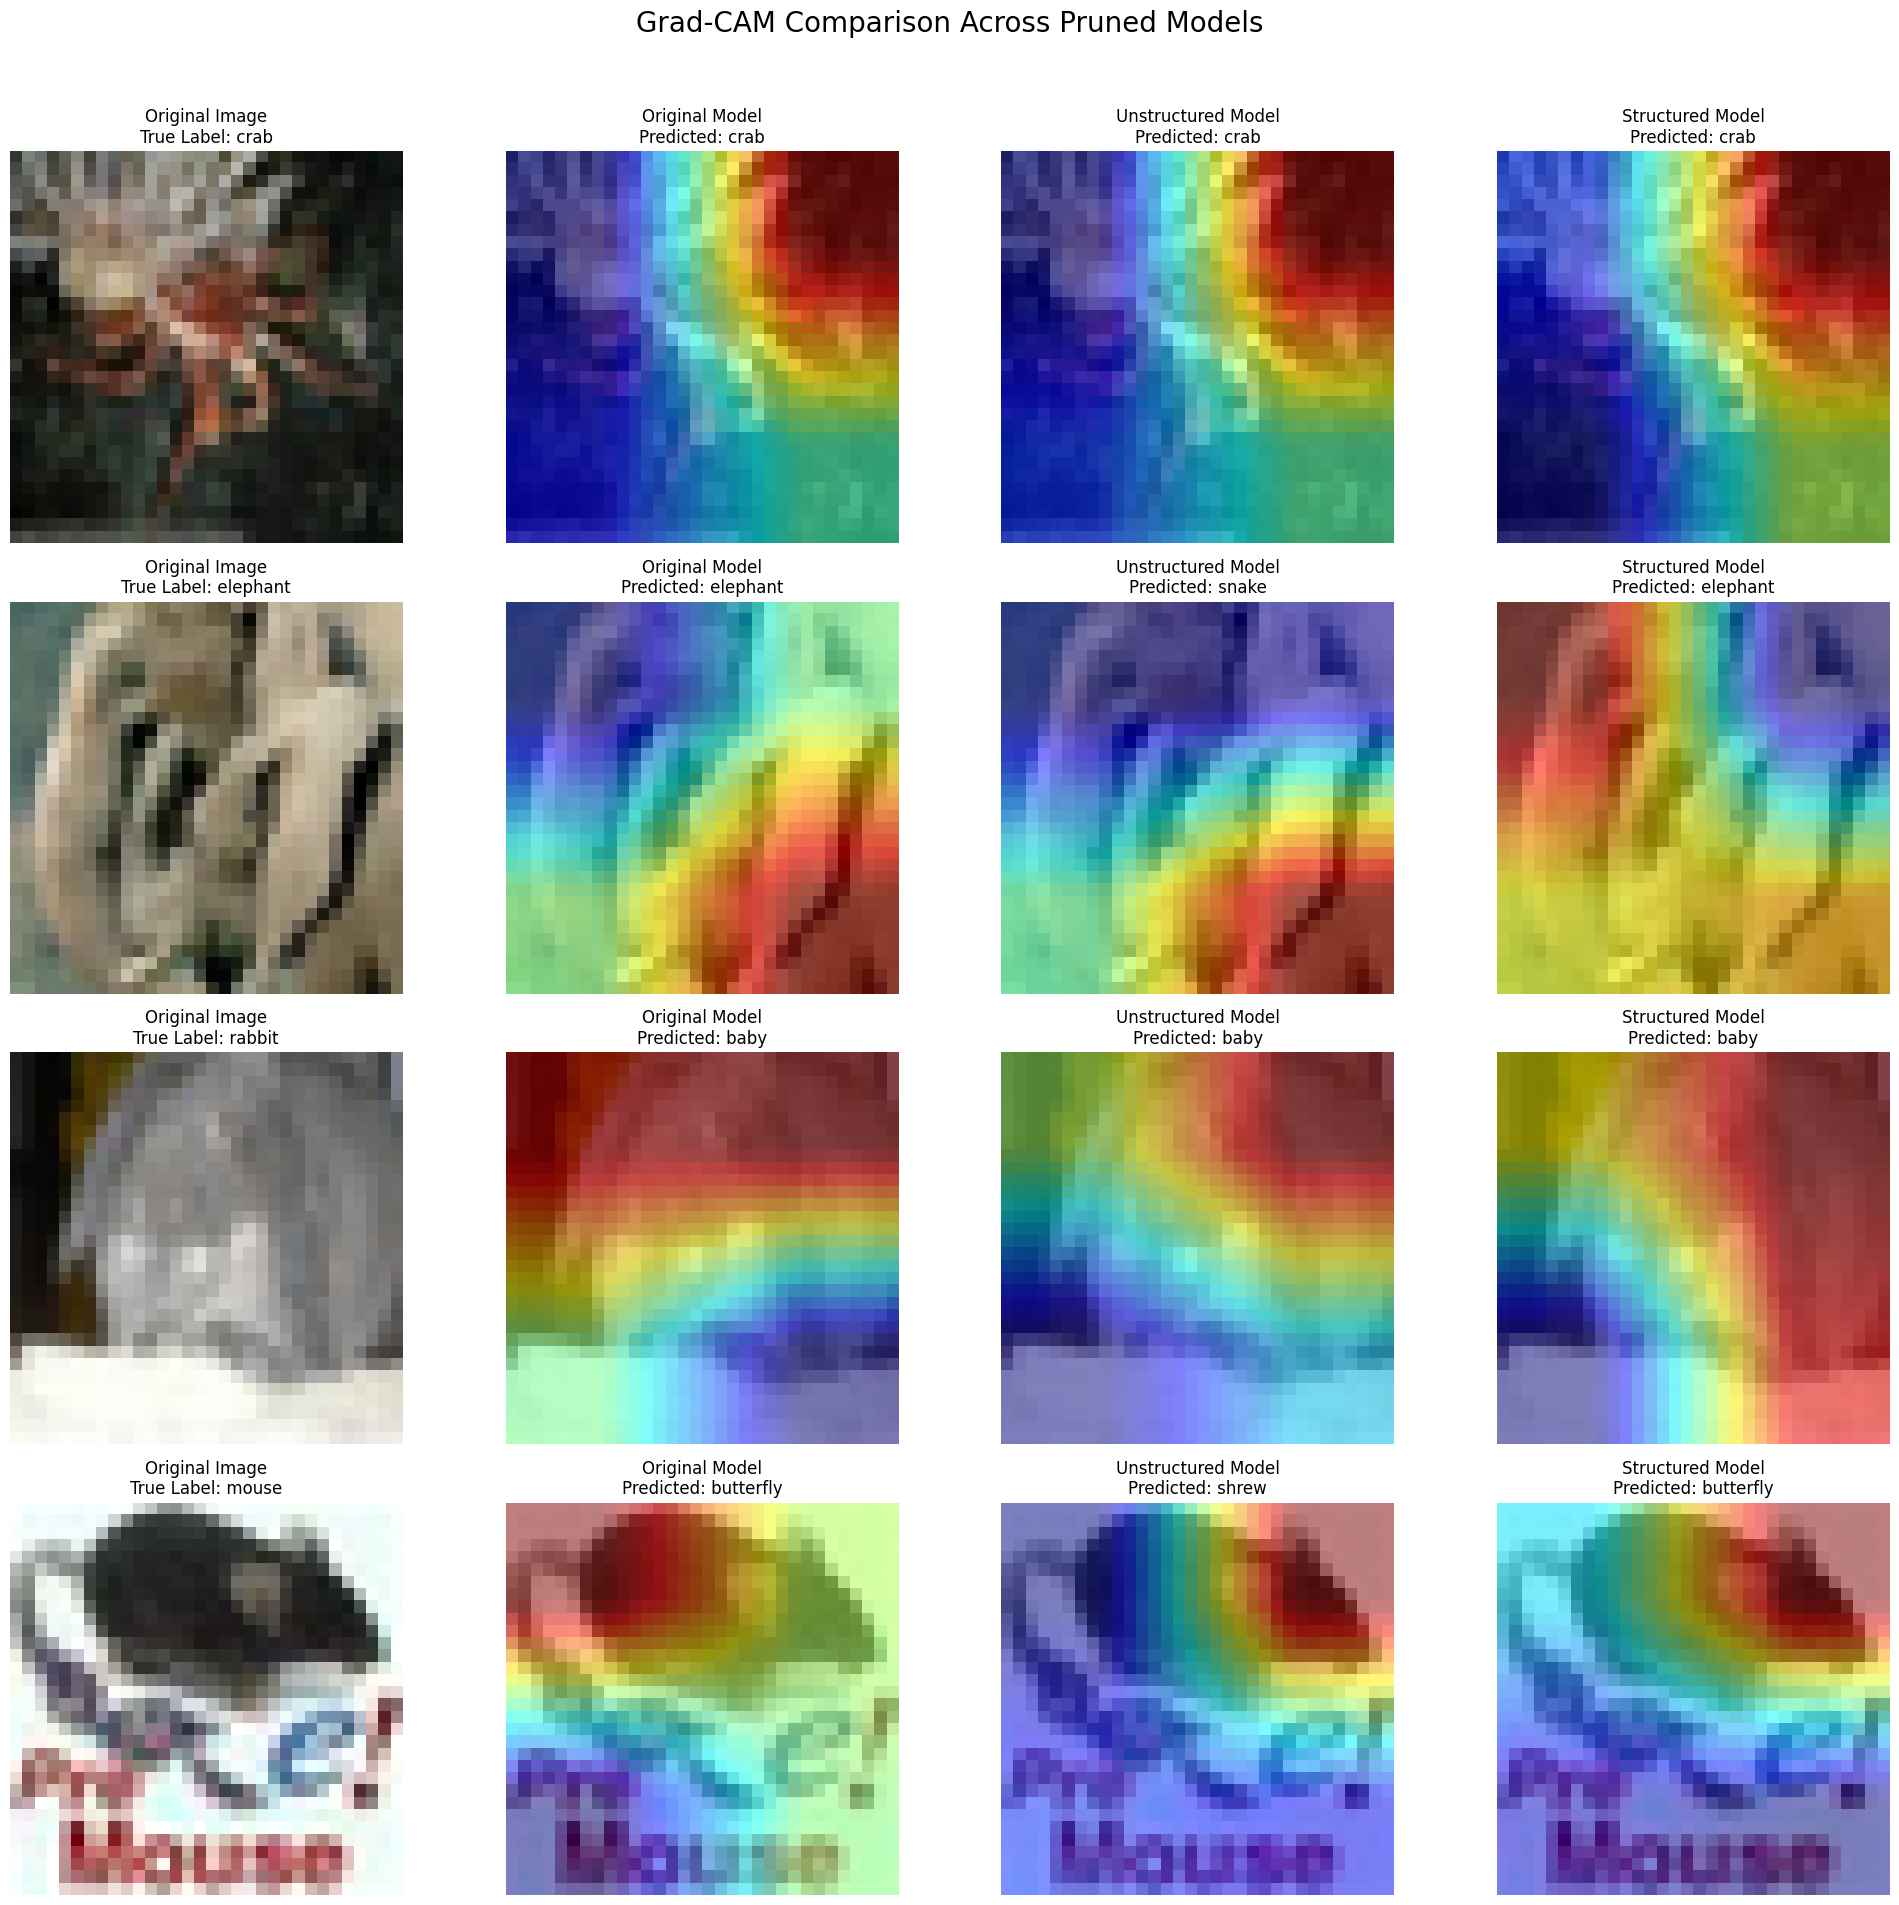

In [38]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image
import cv2

# --- Grad-CAM Visualization Function ---
def visualize_grad_cam(model, target_layers, img_tensor, img_pil, targets):
    # The target_layers argument should be a list of layers.
    with GradCAM(model=model, target_layers=target_layers) as cam:
        grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]

        img_np = np.array(img_pil).astype(np.float32) / 255
        visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    return visualization

# --- Image and Target Selection ---
image_indices = [100, 500, 1000, 1500]
num_images = len(image_indices)

# --- Prepare Models for Comparison ---
original_model.to(DEVICE).eval()
unstructured_pruned_model.to(DEVICE).eval()
structured_pruned_model.to(DEVICE).eval()

# THE FIX: target_layers are now correctly specified as a list containing the layer object(s).
models_to_compare = {
    "Original": (original_model, [original_model.features[-2]]),
    "Unstructured": (unstructured_pruned_model, [unstructured_pruned_model.features[-2]]),
    "Structured": (structured_pruned_model, [structured_pruned_model.features[-2]])
}

# --- Generate and Plot Visualizations ---
fig, axes = plt.subplots(num_images, 4, figsize=(20, 5 * num_images))
if num_images == 1: axes = np.expand_dims(axes, axis=0)

for row, img_idx in enumerate(image_indices):
    img_pil = Image.fromarray(test_dataset.data[img_idx])
    _, label = test_dataset[img_idx]
    img_tensor = test_dataset.transform(img_pil).unsqueeze(0).to(DEVICE)

    ax = axes[row, 0]
    ax.imshow(img_pil)
    ax.set_title(f"Original Image\nTrue Label: {test_dataset.classes[label]}")
    ax.axis('off')

    targets = [ClassifierOutputTarget(label)]

    col = 1
    for name, (m, layers) in models_to_compare.items():
        pred = m(img_tensor).argmax(dim=1).item()
        pred_class = test_dataset.classes[pred]

        visualization = visualize_grad_cam(m, layers, img_tensor, img_pil, targets)

        ax = axes[row, col]
        ax.imshow(visualization)
        ax.set_title(f"{name} Model\nPredicted: {pred_class}")
        ax.axis('off')
        col += 1

fig.suptitle('Grad-CAM Comparison Across Pruned Models', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

### 3.3 Accuracy vs. Target Sparsity Curve
Finally, we generate a plot to illustrate the direct trade-off between compression and performance. We choose unstructured pruning and apply it at five different global sparsity levels. For each level, we fine-tune the model and record its final accuracy. This curve is a key deliverable that shows how severely performance is affected by increasing levels of pruning.

--- Testing Sparsity: 0.0% ---


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Training:   0%|          | 0/391 [00:00<?, ?it/s]

Training:   0%|          | 0/391 [00:00<?, ?it/s]

Training:   0%|          | 0/391 [00:00<?, ?it/s]

...

Training:   0%|          | 0/391 [00:00<?, ?it/s]

Training:   0%|          | 0/391 [00:00<?, ?it/s]

Training:   0%|          | 0/391 [00:00<?, ?it/s]

Training:   0%|          | 0/391 [00:00<?, ?it/s]

  Best accuracy after fine-tuning: 59.50%


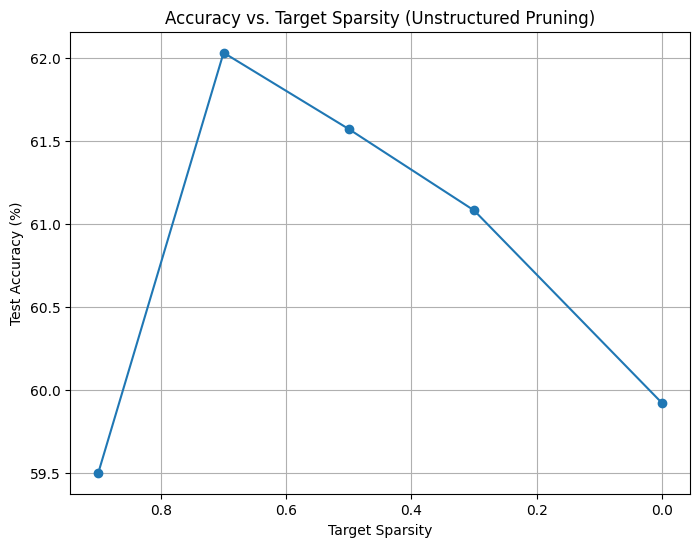

In [39]:
target_sparsities = [0.0, 0.3, 0.5, 0.7, 0.9]
final_accuracies = []

for sparsity in target_sparsities:
    print(f"--- Testing Sparsity: {sparsity:.1%} ---")
    recover_model()

    # Apply uniform sparsity across all prunable layers
    uniform_sparsity_dict = {name: sparsity for name in layer_names}
    pruner = FineGrainedPruner(model, uniform_sparsity_dict)

    # Fine-tune
    num_epochs = 5 # A shorter fine-tuning for this experiment
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0
    for epoch in range(num_epochs):
        train(model, dataloader['train'], criterion, optimizer, callbacks=[lambda: pruner.apply(model)])
        acc = evaluate(model, dataloader['test'], verbose=False)
        if acc > best_acc:
            best_acc = acc

    final_accuracies.append(best_acc)
    print(f"  Best accuracy after fine-tuning: {best_acc:.2f}%")

# Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(target_sparsities, final_accuracies, marker='o', linestyle='-')
plt.title('Accuracy vs. Target Sparsity (Unstructured Pruning)')
plt.xlabel('Target Sparsity')
plt.ylabel('Test Accuracy (%)')
plt.grid(True)
plt.gca().invert_xaxis() # Higher sparsity (more pruning) on the right
plt.show()

### 3.4 Qualitative Analysis and Key Observations

This final section synthesizes the results for the report's discussion.

#### Ease of Application
-   **Unstructured Pruning:** Conceptually simpler. The logic is applied independently to each weight tensor. The main challenge lies in managing the masks, especially during fine-tuning, to ensure pruned weights remain zero.
-   **Structured Pruning:** More complex to implement. Pruning output channels of one layer requires modifying the input channels of the next. This creates inter-layer dependencies and requires physically reconstructing the model or carefully managing indices, which is more error-prone.

#### Hardware Considerations
-   **Unstructured Pruning:** Results in sparse weight matrices. While it dramatically reduces the number of non-zero parameters, it does not reduce the actual size of the weight tensors or the number of MACs in a standard dense matrix multiplication. Achieving a practical speedup requires specialized hardware (e.g., sparse matrix accelerators) or software libraries (e.g., cuSPARSE) that can efficiently handle sparse operations. On standard GPUs and CPUs, the latency reduction is often minimal or even negative due to the overhead of index lookups.
-   **Structured Pruning:** Physically removes filters and channels, creating a smaller, dense model. This directly reduces the number of parameters, the model's memory footprint, and the number of MACs. As a result, it leads to measurable latency improvements on standard hardware like GPUs and CPUs, as the operations are still dense but on smaller tensors. This makes it a much more practical approach for immediate speedup.

#### Inherent Limitations
-   Both methods rely on the "smaller-norm-less-important" heuristic, which is not always optimal.
-   Both require a sensitive fine-tuning phase to recover accuracy. Aggressive pruning can sometimes damage the model beyond recovery.
-   Determining the optimal per-layer sparsity/pruning ratio is a non-trivial hyperparameter search problem, often requiring expensive sensitivity scans.

#### Grad-CAM Analysis Insights
-   *(Observation from the generated plot)* Did pruning force the model to focus on more salient, object-centric features, or did it introduce noise? For example, the pruned models might show a more concentrated heatmap on the object of interest, suggesting they learned to be more efficient. Conversely, a diffuse or incorrect heatmap might indicate that crucial features were erroneously removed.

#### Final Recommendation
-   For pure model size reduction (storage), **unstructured pruning** is superior, as it can achieve very high sparsity ratios with good accuracy recovery.
-   For achieving practical inference speedup on general-purpose hardware (GPUs/CPUs), **structured pruning** is the clear winner. The trade-off is often a slightly larger drop in accuracy for the same level of parameter reduction compared to unstructured pruning, but the gains in latency are real and significant.